In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat
import module.stealthy_attack as attack
from scipy.stats import chi2
import lib.ioFile as ioFile
import lib.graph  as graph
import random
import networkx as nx

PowerID= 14
calculateStateImpact= False

file_name= f'matpower/test_data/DC_case{PowerID}_.mat' #14, 118, 30, 57
file_namesmoothXlsx= f'data/results2/smooth-change/results{PowerID}.xlsx' #14, 118, 30, 57
file_namestepXlsx= f'data/results2/step-change/results{PowerID}.xlsx' #14, 118, 30, 57
file_namepreviousXlsx= f'data/fdia_modify_results{PowerID}.xlsx' #14, 118, 30, 57
file_namespecialXlsx= f'data/fdia_results{PowerID}.xlsx' #14, 118, 30, 57
# Access a variable inside the .mat file
_, phaseData, H, A, _= ioFile.read_mat_power(file_name, normalize= False)
print(H.shape)
G, node_pair2id = graph.from_A_to_G(A)

def add_noise_to_data(data, std= 0):
    noisedData= data.copy()
    noisedData+= np.random.randn(data.shape[0], data.shape[1])*std#uniform distribution over [0, 1]
    return noisedData

def read_excel_power(file_path= "", id1= 0, id2= 1):
    pfData = pd.read_excel(file_path, engine='openpyxl', sheet_name=id1, parse_dates=['Timestamp'])
    phaseData = pd.read_excel(file_path, engine='openpyxl', sheet_name=id2, parse_dates=['Timestamp'])
    pfData.set_index('Timestamp', inplace=True)
    phaseData.set_index('Timestamp', inplace=True)
    pfData= pfData.to_numpy(dtype= np.float64)
    phaseData= phaseData.to_numpy(dtype= np.float64)
    return pfData, phaseData

attackPfData, attackPhaseData= read_excel_power(file_namestepXlsx, 0, 1)
# attackPfData, attackPhaseData= read_excel_power(file_namepreviousXlsx, 2, 3)
# attackPfData, attackPhaseData= read_excel_power(file_namestepXlsx, 0, 1)
# attackPfData, attackPhaseData= read_excel_power(file_namespecialXlsx, 0, 1)
if calculateStateImpact:
    attackPfData, attackPhaseData= read_excel_power(file_namespecialXlsx, 0, 1)
    normalPfData, normalPhaseData= read_excel_power(file_namespecialXlsx, 2, 3)
    normalPhaseData= np.linalg.pinv(H).dot(normalPfData.T).T
    normalPhaseData= normalPhaseData-normalPhaseData[:, 0:1]

attackPhaseData= np.linalg.pinv(H).dot(attackPfData.T).T
attackPhaseData= attackPhaseData-attackPhaseData[:, 0:1]
normalPfData= H.dot(attackPhaseData.T).T

C:\Users\30678\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(20, 14)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


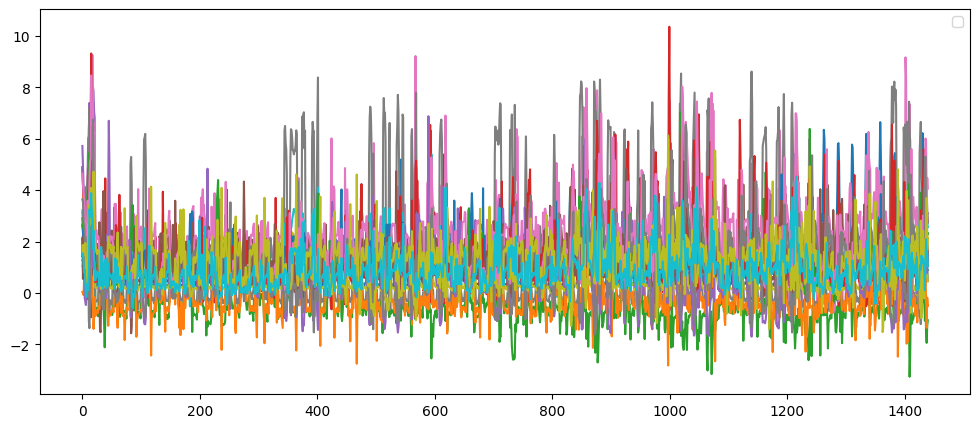

In [2]:
plt.figure(figsize=(12, 5))

plt.plot(attackPfData)
plt.legend()
# print(np.linalg.norm(attackPhaseData-normalPhaseData, axis= 1).sum())
# plt.xlabel("Time points")
# plt.ylabel("Estimated state")

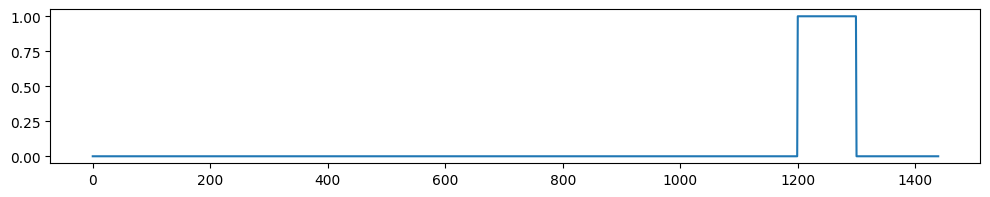

In [3]:
attackPeriod= np.linalg.norm((normalPfData-attackPfData)[:, ], axis= 1)>1e-5
plt.figure(figsize=(12, 2))
plt.plot(attackPeriod)

In [4]:
np.random.seed(3)
noiseVector= np.random.randn(attackPfData.shape[0], attackPfData.shape[1])

In [5]:
from skimage.filters import threshold_li
from scipy.stats import chi2, chisquare
import tqdm
trainDataNum= H.shape[0]+1
print(trainDataNum)
# RRT= np.random.rand(trainDataNum, trainDataNum)
def attack_detection_reconstruction_error(trainData, testData, groundTruth, rank= 1, dataRound= ""):
    trainData= trainData.copy()
    testData= testData.copy()
    testData= testData/np.linalg.norm(testData, 2, axis=1, keepdims= True)
    testData= testData-np.mean(testData, 0, keepdims= True)
    # Perform SVD
    leftMat= (trainData.T@trainData)
    eigV, U= np.linalg.eig(leftMat)
    
    # rank= np.sum(eigV>1e-2)

    # U, _, _ = np.linalg.svd(H, full_matrices=True)
    # Select columns of U corresponding to non-zero singular values
    # Obtian null space
    if rank== U.shape[1]:
        return 0, 0
    A = U[:, rank:]
    # perform test
    A_pinv = np.linalg.pinv(A)
    J= A.dot(A_pinv)
    Error= J.dot(testData.T)
    residual= np.linalg.norm(Error, axis= 0)
    thresholdT= threshold_li(residual)
    # numNormal= np.sum(1-groundTruth)
    # sortedResidual= np.sort(residual)
    # thresholdT= sortedResidual[numNormal-1]
    predict= (residual>thresholdT)
    cross= groundTruth*predict
    precision= cross.sum()/(predict.sum()+1e-5)
    recall= cross.sum()/(groundTruth.sum()+1e-5)
    # print(precision, recall)
    # plt.figure(figsize=(12, 4))
    # plt.axis("off")
    # plt.plot(residual)
    # plt.plot([thresholdT for _ in range(residual.shape[0])])
    # plt.title(f"Detction on round {dataRound} data")
    # plt.xlabel("Time points")
    # plt.ylabel("Reconstruction error")
    # plt.yscale("log")
    return precision, recall

# precision, recall= attack_detection_reconstruction_error(newAttackPfData[:60, ]+noiseVector[:60, ]*0, newAttackPfData+noiseVector*0, attackPeriod, H.shape[1]-1)
mapPrecisionT= np.zeros((100, 100))
mapRecalT= np.zeros((100, 100))
originStdMeasurement= np.std((normalPfData-attackPfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
mapImpact= np.zeros((100, 100))
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []

for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-attackPfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= newAttackPfData+noiseVector*noiseStd
        precision, recall= attack_detection_reconstruction_error(newAttackPfData[:trainDataNum, ]+noiseVector[:trainDataNum, ]*noiseStd, 
                                                                 tmpMeasurement, attackPeriod, rank= H.shape[1]-1)
        mapPrecisionT[j, i]= precision
        mapRecalT[j, i]= recall
        tmpPhaseData= np.linalg.pinv(H).dot(tmpMeasurement.T).T
        tmpPhaseData= tmpPhaseData-tmpPhaseData[:, 0:1]

        impactTmp= 0
        if calculateStateImpact:
            normalPhaseData= normalPhaseData-normalPhaseData[:, 0:1]
            impactTmp= (np.linalg.norm(tmpPhaseData-normalPhaseData, axis=1)*attackPeriod).sum()/attackPeriod.sum()
        baseRat= np.sqrt(H.shape[0])*ratio2
        mapImpact[j, i]= impactTmp



21


100%|██████████| 100/100 [00:24<00:00,  4.01it/s]


In [70]:
def get_random_connected_subgraph(G: nx.Graph, m: int) -> nx.Graph:

    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    if num_nodes == 0:
         raise ValueError("Input graph cannot be empty.")
            
    if m > num_edges:
        raise ValueError(f"Requested m ({m}) is larger than the total number of edges in G ({num_edges}).")

    # Handle graph with 1 node (no edges possible unless m=0, handled above)
    if num_nodes == 1 and m > 0:
         raise ValueError(f"Cannot select {m} edges from a graph with only 1 node.")


    # --- Algorithm Start ---
    subgraph_nodes = set()
    subgraph_edges = set() # Store edges as sorted tuples to handle undirectedness

    # 1. Initialize: Start with a random node
    start_node = random.choice(list(G.nodes()))
    subgraph_nodes.add(start_node)

    # 2. Grow the subgraph iteratively
    while len(subgraph_edges) < m:
        # Identify potential edges to add:
        # Edges connecting a node *in* the subgraph to any node (in or out),
        # provided the edge is not already selected.
        potential_edges = []
        for node_in_subgraph in subgraph_nodes:
            for neighbor in G.neighbors(node_in_subgraph):
                # Ensure consistent edge representation (e.g., (smaller_node, larger_node))
                edge = tuple(sorted((node_in_subgraph, neighbor)))
                if edge not in subgraph_edges:
                    potential_edges.append(edge)

        # Check if we can still add edges
        if not potential_edges:
            # This should ideally not happen if m <= num_edges and G is connected,
            # because a connected graph always allows adding edges until all are included.
            # However, it's a safeguard.
            raise RuntimeError(f"Could not find new edge to add while having only {len(subgraph_edges)} edges (target m={m}). Is the original graph truly connected?")

        # 3. Select a random edge from the potential candidates
        chosen_edge = random.choice(potential_edges)

        # 4. Add the chosen edge and its endpoints to the subgraph
        subgraph_edges.add(chosen_edge)
        subgraph_nodes.update(chosen_edge) # Add both nodes of the edge


    return list(subgraph_nodes), subgraph_edges


In [71]:

noiseStd= np.sqrt(np.square(1e-2)/H.shape[0])
ratio= 0.1/LenofOriginAttack/100
measurementList= list(range(0, H.shape[0]))
delMeaNum= 13
repeatNum= 1000

scale= (0.0664)*ratio*1e3
newAttackPfData= (normalPfData-attackPfData)*scale+normalPfData
stdOfMeasurement= np.std((normalPfData-newAttackPfData))
lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
tmpMeasurement= newAttackPfData+noiseVector*noiseStd
trainData= newAttackPfData[:trainDataNum, ]+noiseVector[:trainDataNum, ]*noiseStd
testData= tmpMeasurement
resultMatrix= np.zeros((H.shape[0], repeatNum))
impactMatrix= np.zeros((H.shape[0], repeatNum))
linkCentrality= np.zeros(H.shape[0])
linkCentralityCount= np.zeros(H.shape[0])
for i in tqdm.tqdm(range(0, H.shape[0])):
    for j in range(repeatNum):
        random.shuffle(measurementList)
        selected_nodes, selected_edges= get_random_connected_subgraph(G, H.shape[0]-i)
        selected_edges= [node_pair2id[i] for i in selected_edges]
        MeasurementSub= newAttackPfData[:, selected_edges]
        precision, recall= attack_detection_reconstruction_error(trainData[:, selected_edges], testData[:, selected_edges], attackPeriod, rank= len(selected_nodes)-1)
        f1= 2*precision*recall/(precision+recall+1e-6)
        resultMatrix[i, j]= f1
        linkCentrality[selected_edges]+= f1/len(selected_edges)
        linkCentralityCount[selected_edges]+= 1
        if calculateStateImpact:
            Hsub= H[selected_edges, :]
            Hsub= Hsub[:, selected_nodes]
            HsubPinv= np.linalg.pinv(Hsub)
            tmpPhaseData= HsubPinv.dot(MeasurementSub.T).T
            tmpPhaseData= tmpPhaseData- tmpPhaseData[:, 0:1]
            subNormalPhaseData= normalPhaseData[:, selected_nodes]
            subNormalPhaseData= subNormalPhaseData- subNormalPhaseData[:, 0:1]
            impactTmp= (np.linalg.norm(subNormalPhaseData-tmpPhaseData, axis= 1)*attackPeriod).sum()/attackPeriod.sum()
            impactMatrix[i, j]= impactTmp
        


100%|██████████| 20/20 [00:12<00:00,  1.61it/s]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0, 0.5, 'Centrality value($\\times 100$)')

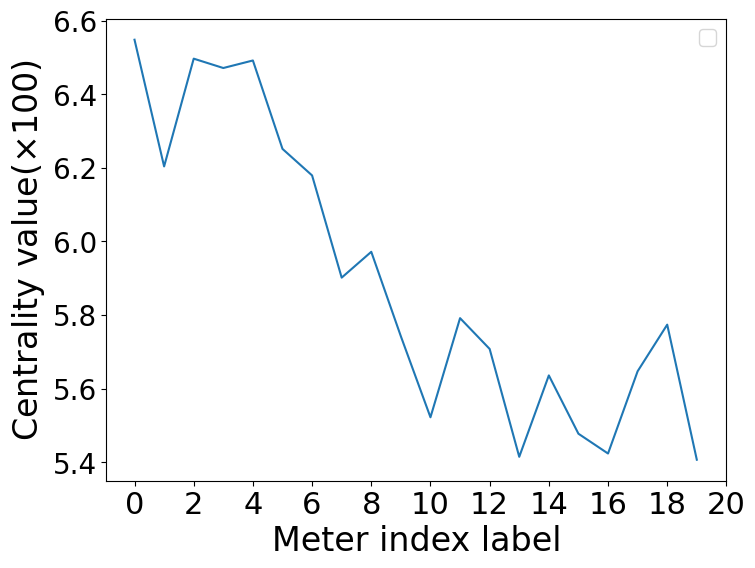

In [72]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(8, 6))
tickInterval= 2
plt.plot(linkCentrality/linkCentralityCount)

formatter = FuncFormatter(lambda val, pos: f'{val*100:.2}')
plt.tick_params(axis='y', labelsize=20)
plt.gca().yaxis.set_major_formatter(formatter)
plt.xticks(ticks= [i*tickInterval for i in range((linkCentrality.shape[0]+tickInterval)//tickInterval)],
            labels= [i*tickInterval for i in range((linkCentrality.shape[0]+tickInterval)//tickInterval)], fontsize= 22)
plt.legend()
plt.xlabel("Meter index label", fontsize = 24)
plt.ylabel(r"Centrality value($\times 100$)", fontsize= 24)


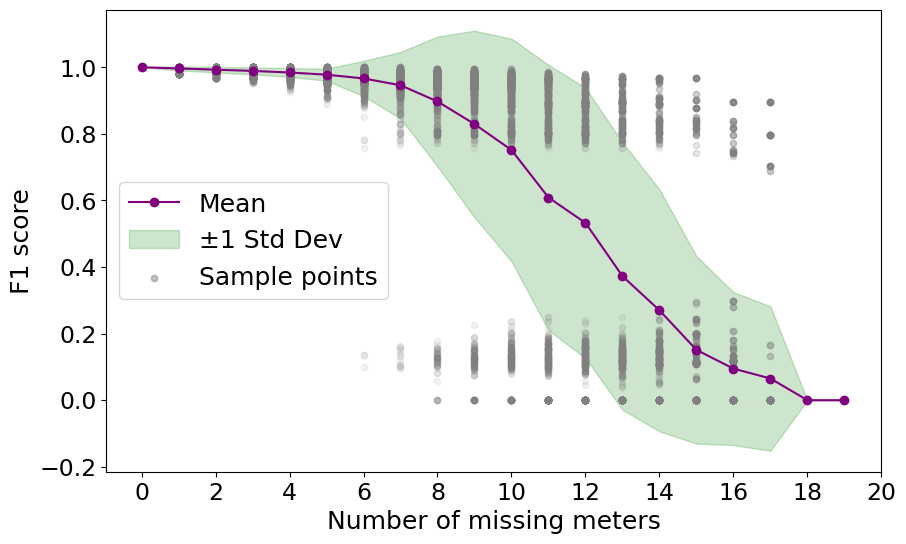

In [73]:
matrixToplot= resultMatrix#resultMatrix ， impactMatrix
tickInterval= 2
fontsize= 18
plt.figure(figsize=(10, 6))
means = np.mean(matrixToplot, axis=1)
stds = np.std(matrixToplot, axis=1)
x = np.arange(matrixToplot.shape[0])
plt.plot(x, means, label='Mean', color='Purple', marker='o')
plt.fill_between(x, means - stds, means + stds, alpha=0.2, label='±1 Std Dev', color='green')
for i in range(matrixToplot.shape[0]):
    plt.scatter([i]*matrixToplot.shape[1], matrixToplot[i, :], alpha=0.1, color='gray', s=20)
plt.scatter([i]*matrixToplot.shape[1], matrixToplot[i, :], alpha=0.5, color='gray', s=20, label='Sample points')
plt.xticks(ticks= [i*tickInterval for i in range((matrixToplot.shape[0]+tickInterval)//tickInterval)],
            labels= [i*tickInterval for i in range((matrixToplot.shape[0]+tickInterval)//tickInterval)], fontsize= fontsize-1)
plt.tick_params(axis='y', labelsize= fontsize-1)
plt.xlabel("Number of missing meters", fontsize= fontsize)
plt.ylabel("F1 score", fontsize= fontsize)# F1 score/ State deviation
plt.legend(fontsize= fontsize)

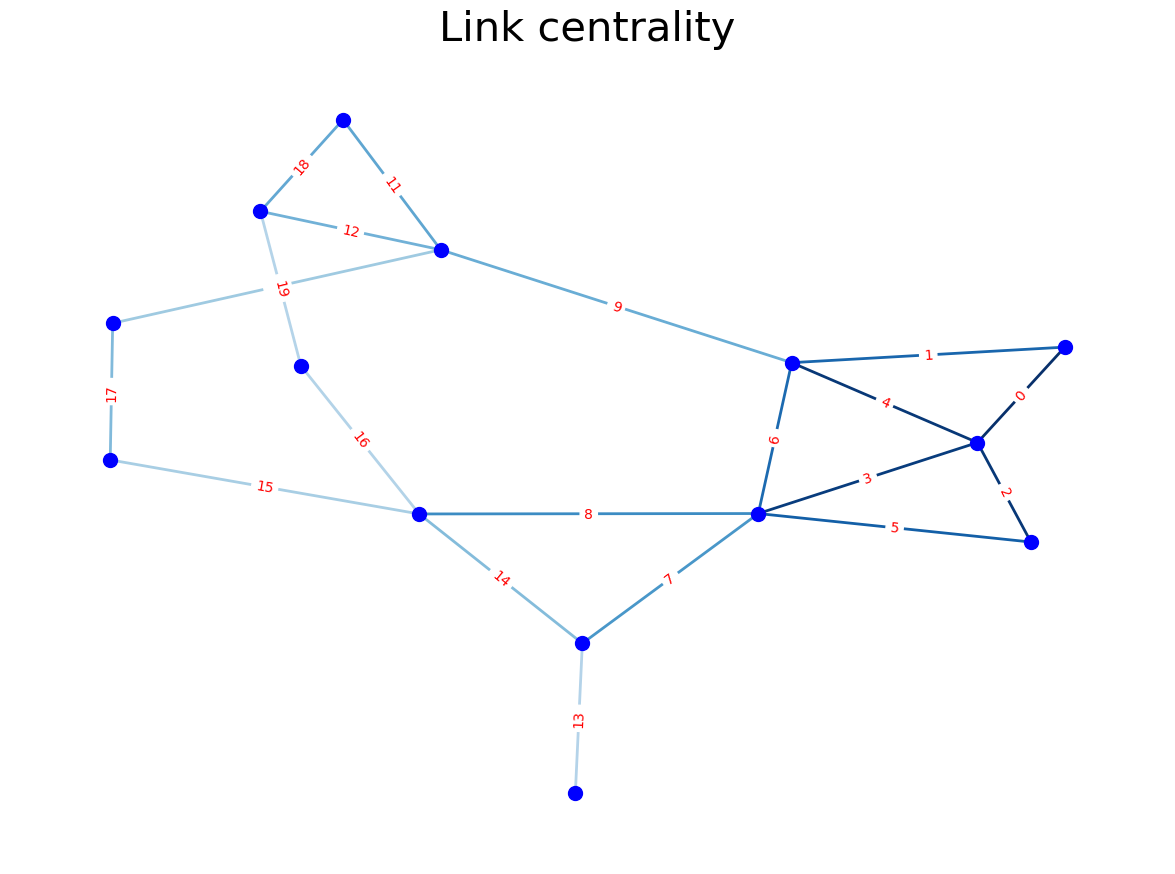

In [74]:
import networkx as nx
import matplotlib.pyplot as plt

for u,v in node_pair2id:
    G[u][v]["weight"]= (linkCentrality/linkCentralityCount)[node_pair2id[(u, v)]]
    G[u][v]["label"]= node_pair2id[(u, v)]
    # print(G[u][v])
plt.figure(figsize=(12, 9))

# Extracting edge weights into a list
weights = [G[u][v]['weight'] for u, v in G.edges()]
# Plotting the graph
pos = nx.spring_layout(G, iterations= 100)  # Layout for the graph
# Drawing nodes
nx.draw_networkx_nodes(G, pos, node_color='blue', node_size=100)
# Drawing edges with weights as edge labels
nx.draw_networkx_edges(G, pos, width=2, edge_color= weights, edge_cmap=plt.cm.Blues,
                        edge_vmax= np.max(linkCentrality/linkCentralityCount), edge_vmin= np.min(linkCentrality/linkCentralityCount)/1.1)
# Adding labels to edges
edge_labels = {(u, v): G[u][v]['label'] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size= 10, alpha= 1)
# Displaying the plot
plt.axis('off')
plt.title("Link centrality", fontsize= 30)
plt.tight_layout()
plt.show()


In [75]:

def attack_detection_reconstruction_error_no(trainData, testData, groundTruth, rank, thresholdT= None, dataRound= ""):
    trainData= trainData.copy()
    testData= testData.copy()
    # testData= testData/np.linalg.norm(testData, 2, axis=1, keepdims= True)
    # testData= testData-np.mean(testData, 0, keepdims= True)
    
    # Perform SVD
    leftMat= trainData.T@trainData
    S, U= np.linalg.eig(leftMat)
    # S= np.sqrt(np.abs(np.real(S)))
    # energy= np.sum(S[:rank])
    # U, _, _ = np.linalg.svd(H, full_matrices=True)
    # Select columns of U corresponding to non-zero singular values
    # Obtian null space
    A = U[:, rank:]
    # perform test
    A_pinv = np.linalg.pinv(A)
    J= A.dot(A_pinv)
    Error= J.dot(testData.T)
    residual= np.linalg.norm(Error, axis= 0)
    if thresholdT == None:
        thresholdT= threshold_li(residual)
    # numNormal= np.sum(1-groundTruth)
    # sortedResidual= np.sort(residual)
    # thresholdT= sortedResidual[numNormal-1]
    predict= (residual>thresholdT)
    cross= groundTruth*predict
    precision= cross.sum()/(predict.sum()+1e-5)
    recall= cross.sum()/(groundTruth.sum()+1e-5)
    # print(precision, recall)
    # plt.figure(figsize=(12, 4))
    # plt.axis("off")
    # plt.plot(residual)
    # plt.plot([thresholdT for _ in range(residual.shape[0])])
    # plt.title(f"Detction on round {dataRound} data")
    # plt.xlabel("Time points")
    # plt.ylabel("Reconstruction error")
    # plt.yscale("log")
    return precision, recall


# precision, recall= attack_detection_reconstruction_error(newAttackPfData[:60, ]+noiseVector[:60, ]*0, newAttackPfData+noiseVector*0, attackPeriod, H.shape[1]-1)
mapPrecisionTno= np.zeros((100, 100))
mapRecalTno= np.zeros((100, 100))
originStdMeasurement= np.std((normalPfData-attackPfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-attackPfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        precision, recall= attack_detection_reconstruction_error_no(newAttackPfData[:trainDataNum, ]+noiseVector[:trainDataNum, ]*noiseStd, 
                                                                    (newAttackPfData+noiseVector*noiseStd), attackPeriod, H.shape[1]-1)
        mapPrecisionTno[j, i]= precision
        mapRecalTno[j, i]= recall

100%|██████████| 100/100 [00:06<00:00, 14.90it/s]


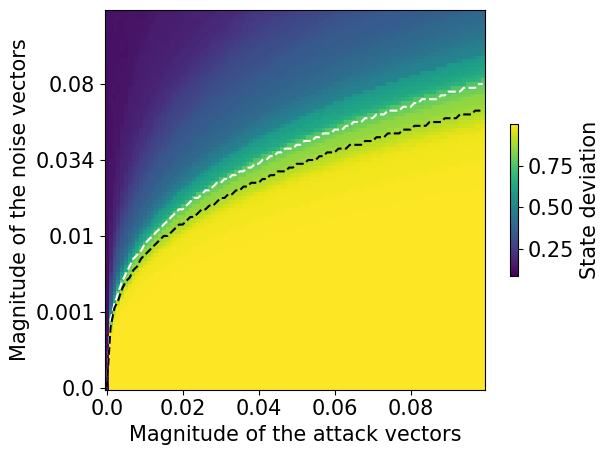

In [85]:
from matplotlib.colors import Normalize
plt.figure()
f1= 2*mapPrecisionT*mapRecalT/(mapRecalT+mapPrecisionT+1e-5)
f1no= 2*mapPrecisionTno*mapRecalTno/(mapRecalTno+mapPrecisionTno+1e-5)

heatToShow= f1no# mapImpact, f1

plotHere= plt.imshow(heatToShow, cmap=  "viridis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
f1sum= (f1>0.9).sum(axis= 0)
f1nosum= (f1no>0.9).sum(axis= 0)
# impact05= (mapImpact<0.05).sum(axis= 0)
# impact05[impact05>99.5]= 99
f1sum[f1sum>98.5]= 98
f1nosum[f1nosum>98.5]= 98
plt.plot(f1sum, linestyle='dashed',  color= "white")
plt.plot(f1nosum, linestyle='dashed', color= "black")
# plt.plot(impact05, linestyle='dashed', color= "red")
colorbar =plt.colorbar(label= "State deviation", shrink=0.4)
colorbar.ax.tick_params(labelsize=15)
plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})
plt.ylabel("Magnitude of the noise vectors")
plt.xlabel("Magnitude of the attack vectors")
plt.tight_layout()
# plt.title("F1")
plt.show()